# Projet 1 — Probabilité de ruine (Modèle de Lundberg)

On considère une compagnie d'assurance dont les fonds propres évoluent selon :
$$U(t) = u + ct - S(t), \quad S(t) = \sum_{k=1}^{N_t} X_k$$

- $c$ : taux de prime (constant)
- $\lambda$ : fréquence des sinistres (loi de Poisson)
- $X_k \sim \mathcal{E}(\mu)$ : ampleur des sinistres (exponentielle de moyenne $\mu$)
- $u$ : fonds propres initiaux

La compagnie fait faillite si $U(t) \leq 0$ pour un certain $t > 0$.

On note :
- $\psi(u, T) = P(\exists t \in [0,T],\ U(t) \leq 0)$ : probabilité de ruine sur horizon fini
- $\psi(u) = P(\exists t \geq 0,\ U(t) \leq 0)$ : probabilité de ruine sur horizon infini

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1 — Condition de viabilité

D'après le corrigé du TD2, en calculant $E[U(t)]$ :
$$E[U(t)] = u + ct - E[S(t)] = u + ct - \lambda\mu t$$

Pour que $E[U(t)] \not\to -\infty$ quand $t \to \infty$, il faut :
$$\boxed{c - \lambda\mu > 0 \iff c > \lambda\mu}$$

**Interprétation :** le taux de prime $c$ doit être strictement supérieur au montant moyen des sinistres par unité de temps $\lambda\mu$, sinon la ruine est certaine ($\psi(u) = 1$ pour tout $u$).

## 2 — Estimation de $\psi(u, T)$ par Monte-Carlo

### Choix des paramètres viables

In [2]:
# Paramètres viables : c > lambda * mu
lambda_ = 1.0   # fréquence des sinistres
mu      = 1.0   # moyenne des sinistres (X ~ Exp(mu))
c       = 1.5   # taux de prime  =>  c - lambda*mu = 0.5 > 0

print(f"Paramètres : λ={lambda_}, μ={mu}, c={c}")
print(f"Condition de viabilité : c - λμ = {c - lambda_*mu:.2f} > 0 ✓")
print()
# Résultat théorique (horizon infini)
rho_theo = (lambda_ * mu) / c
gamma_theo = 1/mu - lambda_/c
print(f"Résultat théorique (TD2) : ψ(u) = ρ·exp(-γu)")
print(f"  ρ = λμ/c = {rho_theo:.4f}")
print(f"  γ = 1/μ - λ/c = {gamma_theo:.4f}")

Paramètres : λ=1.0, μ=1.0, c=1.5
Condition de viabilité : c - λμ = 0.50 > 0 ✓

Résultat théorique (TD2) : ψ(u) = ρ·exp(-γu)
  ρ = λμ/c = 0.6667
  γ = 1/μ - λ/c = 0.3333


### Choix de $u$ et justification

On choisit $u = 2$. Ce choix est motivé par :
- La valeur de $\gamma = 1/\mu - \lambda/c \approx 0.33$ donne $e^{-\gamma u} \approx 0.51$ : la probabilité de ruine n'est ni triviale (proche de 1) ni nulle, ce qui rend l'estimation Monte-Carlo pertinente.
- $u$ est de l'ordre de $1/\gamma$, ce qui est la distance caractéristique du problème.

In [3]:
def simuler_trajectoire(u, c, lambda_, mu, T, dt=0.01):
    """
    Simule une trajectoire de U(t) = u + ct - S(t) sur [0, T].
    Retourne True si ruine (U(t) <= 0 pour un certain t).
    
    Méthode : simulation des temps inter-sinistres (loi Exp(lambda_))
    et des ampleurs (loi Exp(1/mu)).
    """
    t = 0.0
    U = u
    while t < T:
        # Temps jusqu'au prochain sinistre
        tau = np.random.exponential(1.0 / lambda_)
        t_sinistre = t + tau
        if t_sinistre > T:
            # Pas de sinistre avant T, pas de ruine
            return False
        # U croît de c*tau avant le sinistre
        U += c * tau
        # Sinistre : X ~ Exp(1/mu)
        X = np.random.exponential(mu)
        U -= X
        t = t_sinistre
        if U <= 0:
            return True
    return False

def estimer_psi_T(u, c, lambda_, mu, T, N_sim=10000):
    """
    Estime ψ(u, T) par Monte-Carlo avec N_sim simulations.
    """
    ruines = sum(simuler_trajectoire(u, c, lambda_, mu, T) for _ in range(N_sim))
    return ruines / N_sim

### Justification du nombre de simulations

Par l'inégalité de Hoeffding, pour estimer $\psi(u,T) \in [0,1]$ avec une erreur $\varepsilon = 0.01$ et un niveau de confiance $95\%$, il faut :
$$N \geq \frac{\ln(2/\alpha)}{2\varepsilon^2} = \frac{\ln(40)}{0.0002} \approx 18{\,}444$$
On choisit $N = 20\,000$ simulations pour être confortable.

In [8]:
u = 2.0
N_sim = 20000
horizons = [1, 2, 5, 10, 20, 50, 100, 200]

print(f"Estimation de ψ(u={u}, T) pour différents horizons T")
print(f"Nombre de simulations : N = {N_sim}")
print("-" * 45)

psi_T_estimates = []
for T in horizons:
    psi_hat = estimer_psi_T(u, c, lambda_, mu, T, N_sim=N_sim)
    psi_T_estimates.append(psi_hat)
    print(f"  T = {T:5.0f}  =>  ψ̂(u={u}, T) = {psi_hat:.4f}")

psi_theo = rho_theo * np.exp(-gamma_theo * u)
print(f"\nValeur théorique ψ(u={u}) = ρ·exp(-γu) = {psi_theo:.4f}")

Estimation de ψ(u=2.0, T) pour différents horizons T
Nombre de simulations : N = 20000
---------------------------------------------
  T =     1  =>  ψ̂(u=2.0, T) = 0.1052
  T =     2  =>  ψ̂(u=2.0, T) = 0.1609
  T =     5  =>  ψ̂(u=2.0, T) = 0.2472
  T =    10  =>  ψ̂(u=2.0, T) = 0.2960
  T =    20  =>  ψ̂(u=2.0, T) = 0.3209
  T =    50  =>  ψ̂(u=2.0, T) = 0.3403
  T =   100  =>  ψ̂(u=2.0, T) = 0.3431
  T =   200  =>  ψ̂(u=2.0, T) = 0.3444

Valeur théorique ψ(u=2.0) = ρ·exp(-γu) = 0.3423


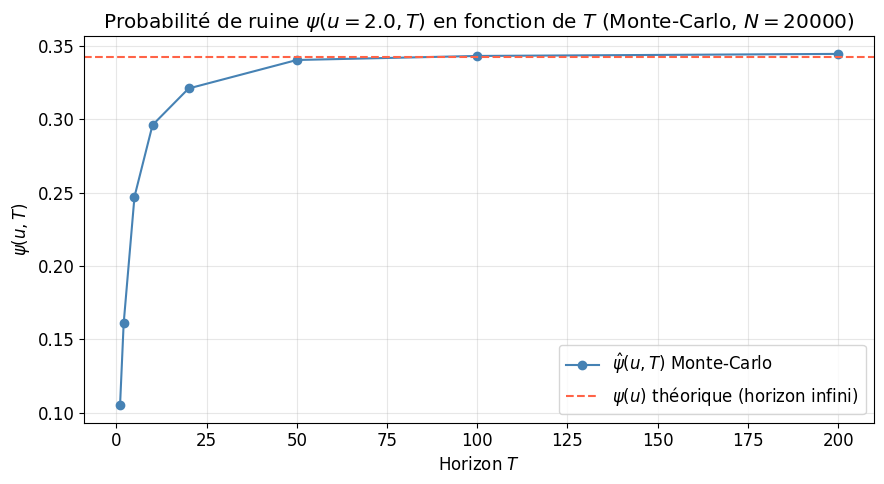

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(horizons, psi_T_estimates, 'o-', color='steelblue', label=r'$\hat{\psi}(u, T)$ Monte-Carlo')
ax.axhline(psi_theo, color='tomato', linestyle='--', label=r'$\psi(u)$ théorique (horizon infini)')
ax.set_xlabel('Horizon $T$')
ax.set_ylabel(r'$\psi(u, T)$')
ax.set_title(rf'Probabilité de ruine $\psi(u={u}, T)$ en fonction de $T$ (Monte-Carlo, $N={N_sim}$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation :** $\psi(u, T)$ est croissante en $T$ et converge vers la valeur théorique $\psi(u)$ quand $T \to \infty$.

## 3 — Estimation de $\psi(u)$ en fonction de $u$ et comparaison avec la formule théorique

Pour des sinistres exponentiels $f(x) = \frac{1}{\mu}e^{-x/\mu}$, la solution de l'équation intégro-différentielle est :
$$\psi(u) = \rho\, e^{-\gamma u}, \quad \text{avec} \quad \rho = \frac{\lambda\mu}{c}, \quad \gamma = \frac{1}{\mu} - \frac{\lambda}{c}$$

On estime $\psi(u)$ ≈ $\psi(u, T_{\infty})$ pour un grand $T_{\infty}$ et on compare.

In [10]:
T_infini = 100   # grand horizon pour approximer ψ(u)
N_sim_q3 = 20000
u_values = np.arange(0, 11, 1)

print(f"Estimation de ψ(u) ≈ ψ(u, T={T_infini}) pour u ∈ [0, 10]")
print(f"Nombre de simulations : N = {N_sim_q3}")
print("-" * 50)

psi_mc = []
psi_theo_vals = []
for u_val in u_values:
    psi_hat = estimer_psi_T(u_val, c, lambda_, mu, T_infini, N_sim=N_sim_q3)
    psi_th  = rho_theo * np.exp(-gamma_theo * u_val)
    psi_mc.append(psi_hat)
    psi_theo_vals.append(psi_th)
    print(f"  u = {u_val:5.1f}  =>  ψ̂(u) = {psi_hat:.4f}   |   ψ_th(u) = {psi_th:.4f}")

Estimation de ψ(u) ≈ ψ(u, T=100) pour u ∈ [0, 10]
Nombre de simulations : N = 20000
--------------------------------------------------
  u =   0.0  =>  ψ̂(u) = 0.6680   |   ψ_th(u) = 0.6667
  u =   1.0  =>  ψ̂(u) = 0.4786   |   ψ_th(u) = 0.4777
  u =   2.0  =>  ψ̂(u) = 0.3418   |   ψ_th(u) = 0.3423
  u =   3.0  =>  ψ̂(u) = 0.2429   |   ψ_th(u) = 0.2453
  u =   4.0  =>  ψ̂(u) = 0.1766   |   ψ_th(u) = 0.1757
  u =   5.0  =>  ψ̂(u) = 0.1303   |   ψ_th(u) = 0.1259
  u =   6.0  =>  ψ̂(u) = 0.0888   |   ψ_th(u) = 0.0902
  u =   7.0  =>  ψ̂(u) = 0.0644   |   ψ_th(u) = 0.0646
  u =   8.0  =>  ψ̂(u) = 0.0466   |   ψ_th(u) = 0.0463
  u =   9.0  =>  ψ̂(u) = 0.0335   |   ψ_th(u) = 0.0332
  u =  10.0  =>  ψ̂(u) = 0.0257   |   ψ_th(u) = 0.0238


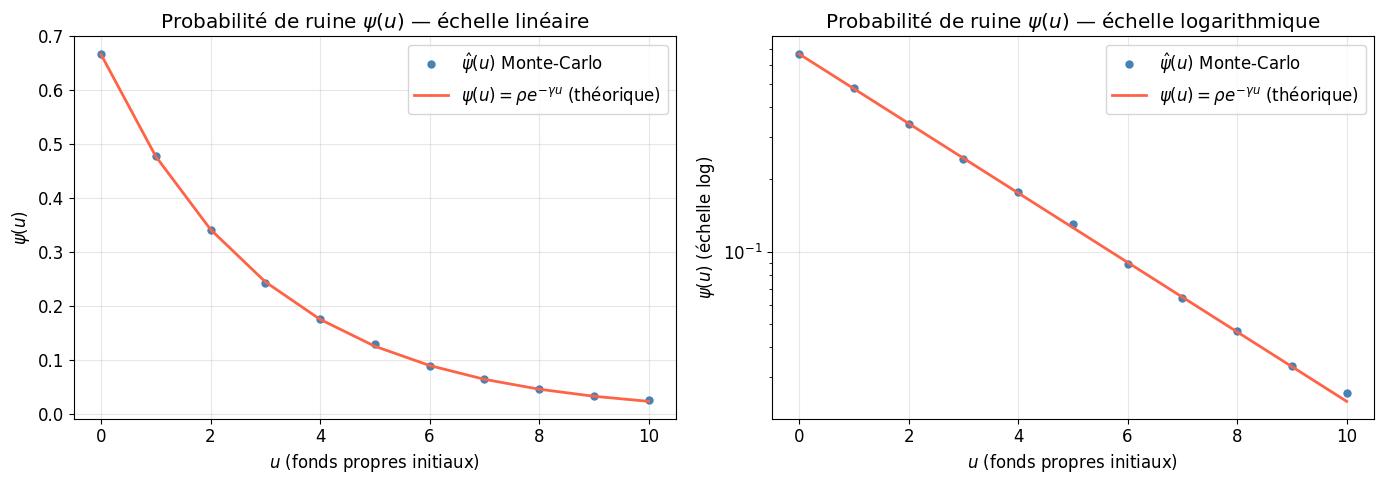


Paramètres théoriques :  ρ = 0.6667,  γ = 0.3333
En échelle log, la courbe théorique est une droite de pente -γ, ce que
les estimations Monte-Carlo confirment.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : échelle linéaire
ax = axes[0]
ax.plot(u_values, psi_mc, 'o', color='steelblue', label=r'$\hat{\psi}(u)$ Monte-Carlo', markersize=5)
ax.plot(u_values, psi_theo_vals, '-', color='tomato', lw=2,
        label=r'$\psi(u) = \rho e^{-\gamma u}$ (théorique)')
ax.set_xlabel('$u$ (fonds propres initiaux)')
ax.set_ylabel(r'$\psi(u)$')
ax.set_title(r'Probabilité de ruine $\psi(u)$ — échelle linéaire')
ax.legend()
ax.grid(True, alpha=0.3)

# Graphique 2 : échelle log (vérifie la décroissance exponentielle)
ax2 = axes[1]
psi_mc_arr = np.array(psi_mc)
mask = psi_mc_arr > 0
ax2.semilogy(u_values[mask], psi_mc_arr[mask], 'o', color='steelblue',
             label=r'$\hat{\psi}(u)$ Monte-Carlo', markersize=5)
ax2.semilogy(u_values, psi_theo_vals, '-', color='tomato', lw=2,
             label=r'$\psi(u) = \rho e^{-\gamma u}$ (théorique)')
ax2.set_xlabel('$u$ (fonds propres initiaux)')
ax2.set_ylabel(r'$\psi(u)$ (échelle log)')
ax2.set_title(r'Probabilité de ruine $\psi(u)$ — échelle logarithmique')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nParamètres théoriques :  ρ = {rho_theo:.4f},  γ = {gamma_theo:.4f}")
print("En échelle log, la courbe théorique est une droite de pente -γ, ce que")
print("les estimations Monte-Carlo confirment.")

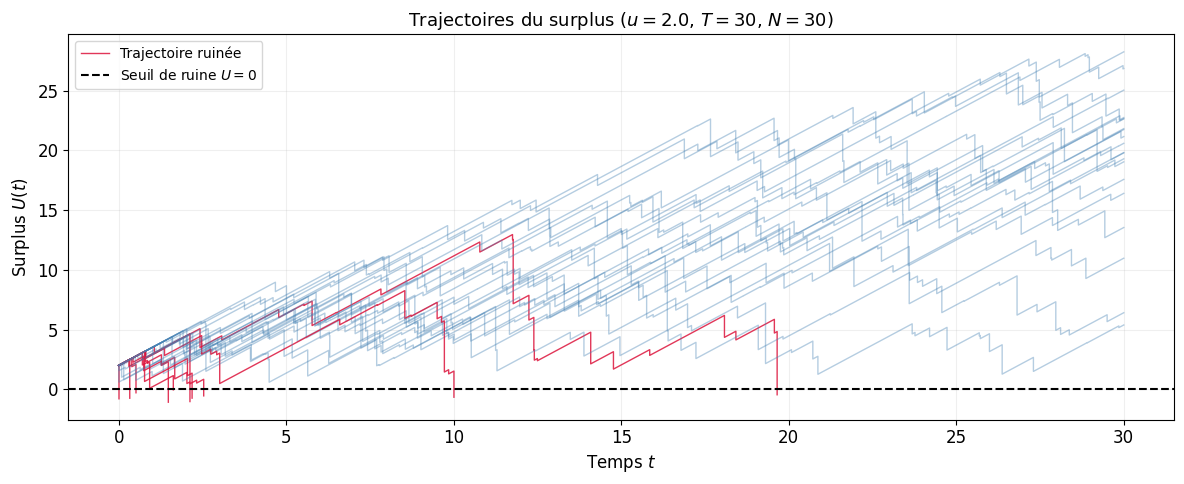

Nombre de ruines observées : 10 / 30


In [23]:
def generate_trajectory(u, T, lam, mu, c, rng):
    """Génère une trajectoire complète du surplus U(t)."""
    times   = [0.0]
    surplus = [u]
    t       = 0.0
    current = u
    ruined  = False

    while True:
        inter = rng.exponential(1 / lam)
        t_new = t + inter

        if t_new > T:
            times.append(T)
            surplus.append(current + c * (T - t))
            break

        # Juste avant le sinistre
        times.append(t_new)
        surplus.append(current + c * inter)

        # Sinistre
        claim   = rng.exponential(1 / mu)
        current = surplus[-1] - claim
        times.append(t_new)
        surplus.append(current)
        t = t_new

        if current <= 0:
            ruined = True
            break

    return np.array(times), np.array(surplus), ruined


rng3           = np.random.default_rng(7)
T_traj         = 30
n_traj         = 30
u_fixed        = u   # capital initial défini plus haut
n_ruined_shown = 0

fig, ax = plt.subplots(figsize=(12, 5))

for i in range(n_traj):
    t_arr, s_arr, ruined = generate_trajectory(u_fixed, T_traj, lambda_, mu, c, rng3)
    color = 'crimson'   if ruined else 'steelblue'
    alpha = 0.85        if ruined else 0.40
    lw    = 1         if ruined else 1
    label = 'Trajectoire ruinée'     if (ruined and n_ruined_shown == 0) else \
            'Trajectoire survivante'  if (not ruined and i == 1)          else None
    if ruined:
        n_ruined_shown += 1
    ax.plot(t_arr, s_arr, color=color, alpha=alpha, linewidth=lw, label=label)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Seuil de ruine $U=0$')
ax.set_xlabel('Temps $t$', fontsize=12)
ax.set_ylabel('Surplus $U(t)$', fontsize=12)
ax.set_title(rf'Trajectoires du surplus ($u={u_fixed}$, $T={T_traj}$, $N={n_traj}$)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('trajectoires.png', dpi=150)
plt.show()

print(f'Nombre de ruines observées : {n_ruined_shown} / {n_traj}')